In [ ]:
!pip install ctgan

In [ ]:
!pip install table-evaluator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from table_evaluator import load_data, TableEvaluator
from ctgan import CTGAN

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FINALFINAL.csv', sep=';', encoding='latin1')
data = data.drop(columns=['CASEID', 'VIN'])

categorical_features = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'ROLLOVER',
    'BODYTYPE',
    'PASSENGERS',
    'BELTED_PASSENGERS',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'

]

numerical_features = [
    'DVTOTAL',
    'SPEEDLIMIT',
]



for col in numerical_features:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data['DVTOTAL'] = data['DVTOTAL'].replace(999, np.nan)
data['SPEEDLIMIT'] = data['SPEEDLIMIT'].replace(999, np.nan)

data = data.dropna()

for col in categorical_features:
    data[col] = data[col].astype(str)

print("shape:", data.shape)
print("missing:\n", data.isna().sum())

ctgan = CTGAN(epochs=len(data), verbose=True)
ctgan.fit(data, discrete_columns=categorical_features)

print("fitted sampler exists:", ctgan._data_sampler is not None)

samples = ctgan.sample(len(data))
samples.head()

shape: (89, 12)
missing:
 FUELTYPE             0
WEATHER              0
SURFCOND             0
DVTOTAL              0
ROLLOVER             0
SPEEDLIMIT           0
BODYTYPE             0
PASSENGERS           0
BELTED_PASSENGERS    0
GAD1                 0
AIRBAG_DEPLOYED      0
FIRE                 0
dtype: int64


Gen. (-00.73) | Discrim. (+00.15): 100%|██████████| 89/89 [00:08<00:00, 10.10it/s]


fitted sampler exists: True


,FUELTYPE,WEATHER,SURFCOND,DVTOTAL,ROLLOVER,SPEEDLIMIT,BODYTYPE,PASSENGERS,BELTED_PASSENGERS,GAD1,AIRBAG_DEPLOYED,FIRE
0,gasoline,snow,dry,-15.543272,no rollover,55.892075,passenger car,1,0,Noncollision,Deployed,missing
1,gasoline,clear,dry,-11.902603,no rollover,42.621509,passenger car,2,1,Front,Deployed,missing
2,gasoline,rain,dry,-18.627503,no rollover,62.422485,pickup/light truck,1,0,Front,Deployed,missing
3,gasoline,clear,dry,1.160013,no rollover,50.742284,SUV,1,1,Front,Deployed,missing
4,gasoline,clear,dry,3.475877,no rollover,30.242554,passenger car,1,1,Front,Deployed,missing


SDG


(89, 12) (89, 12)


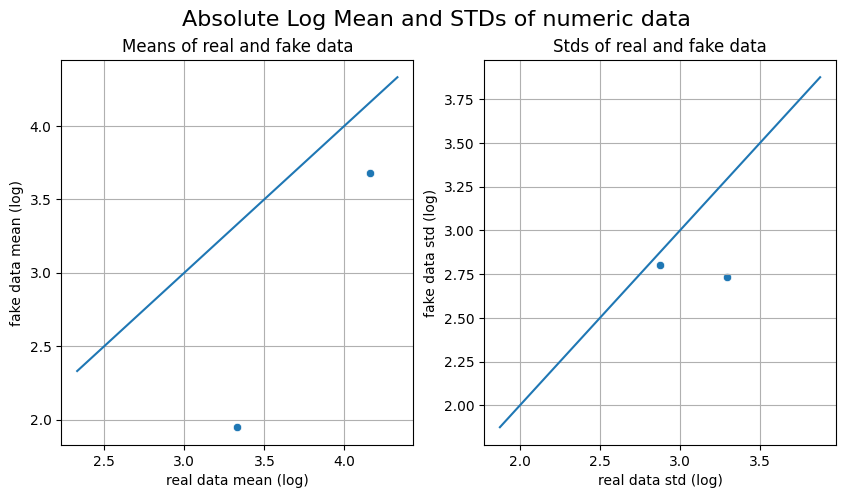

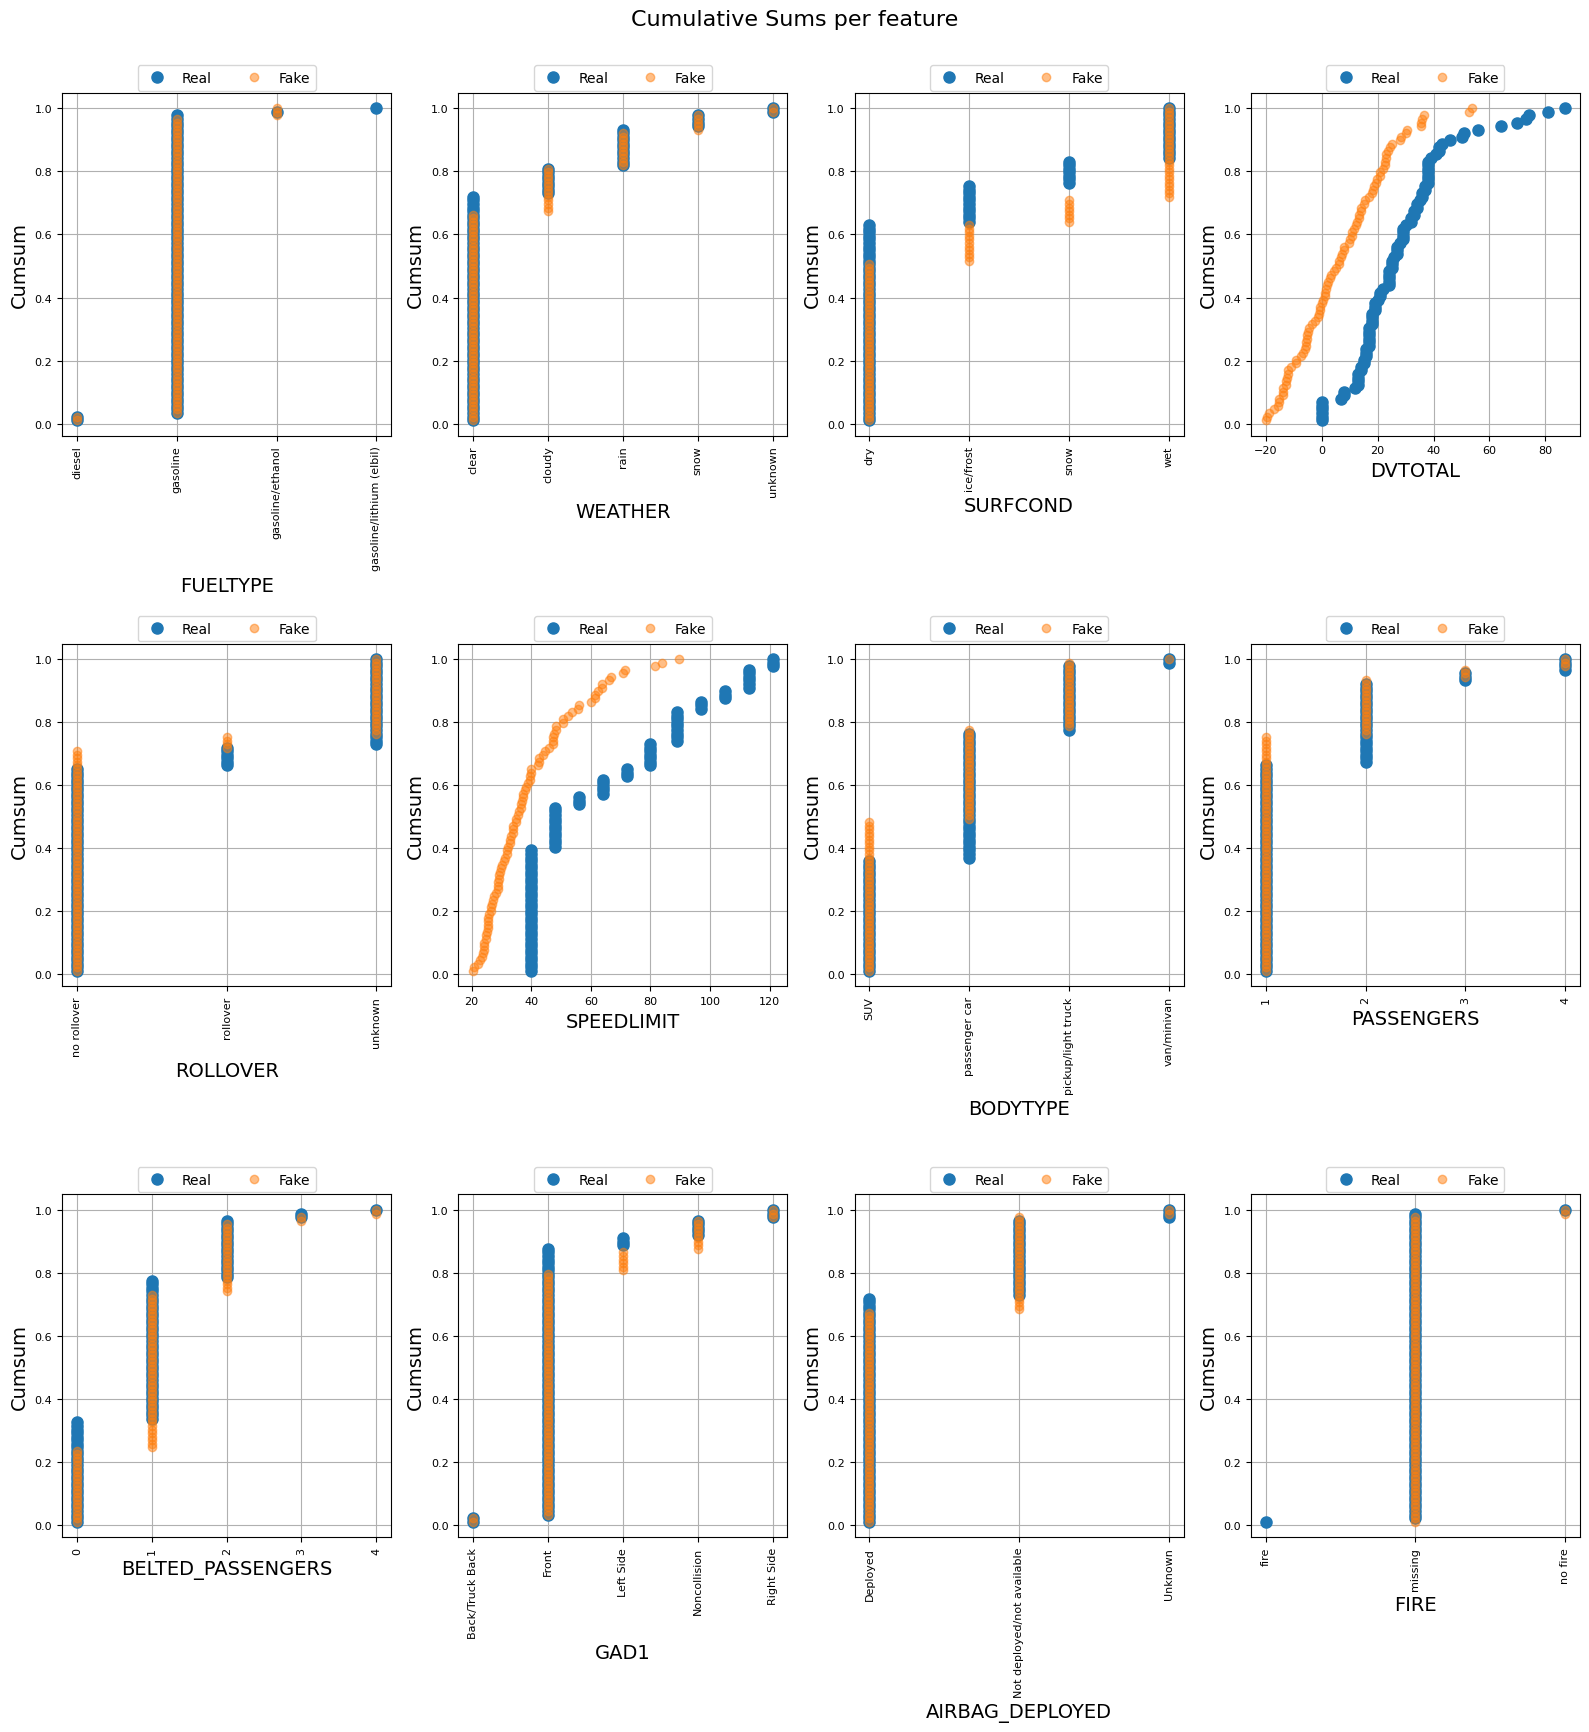

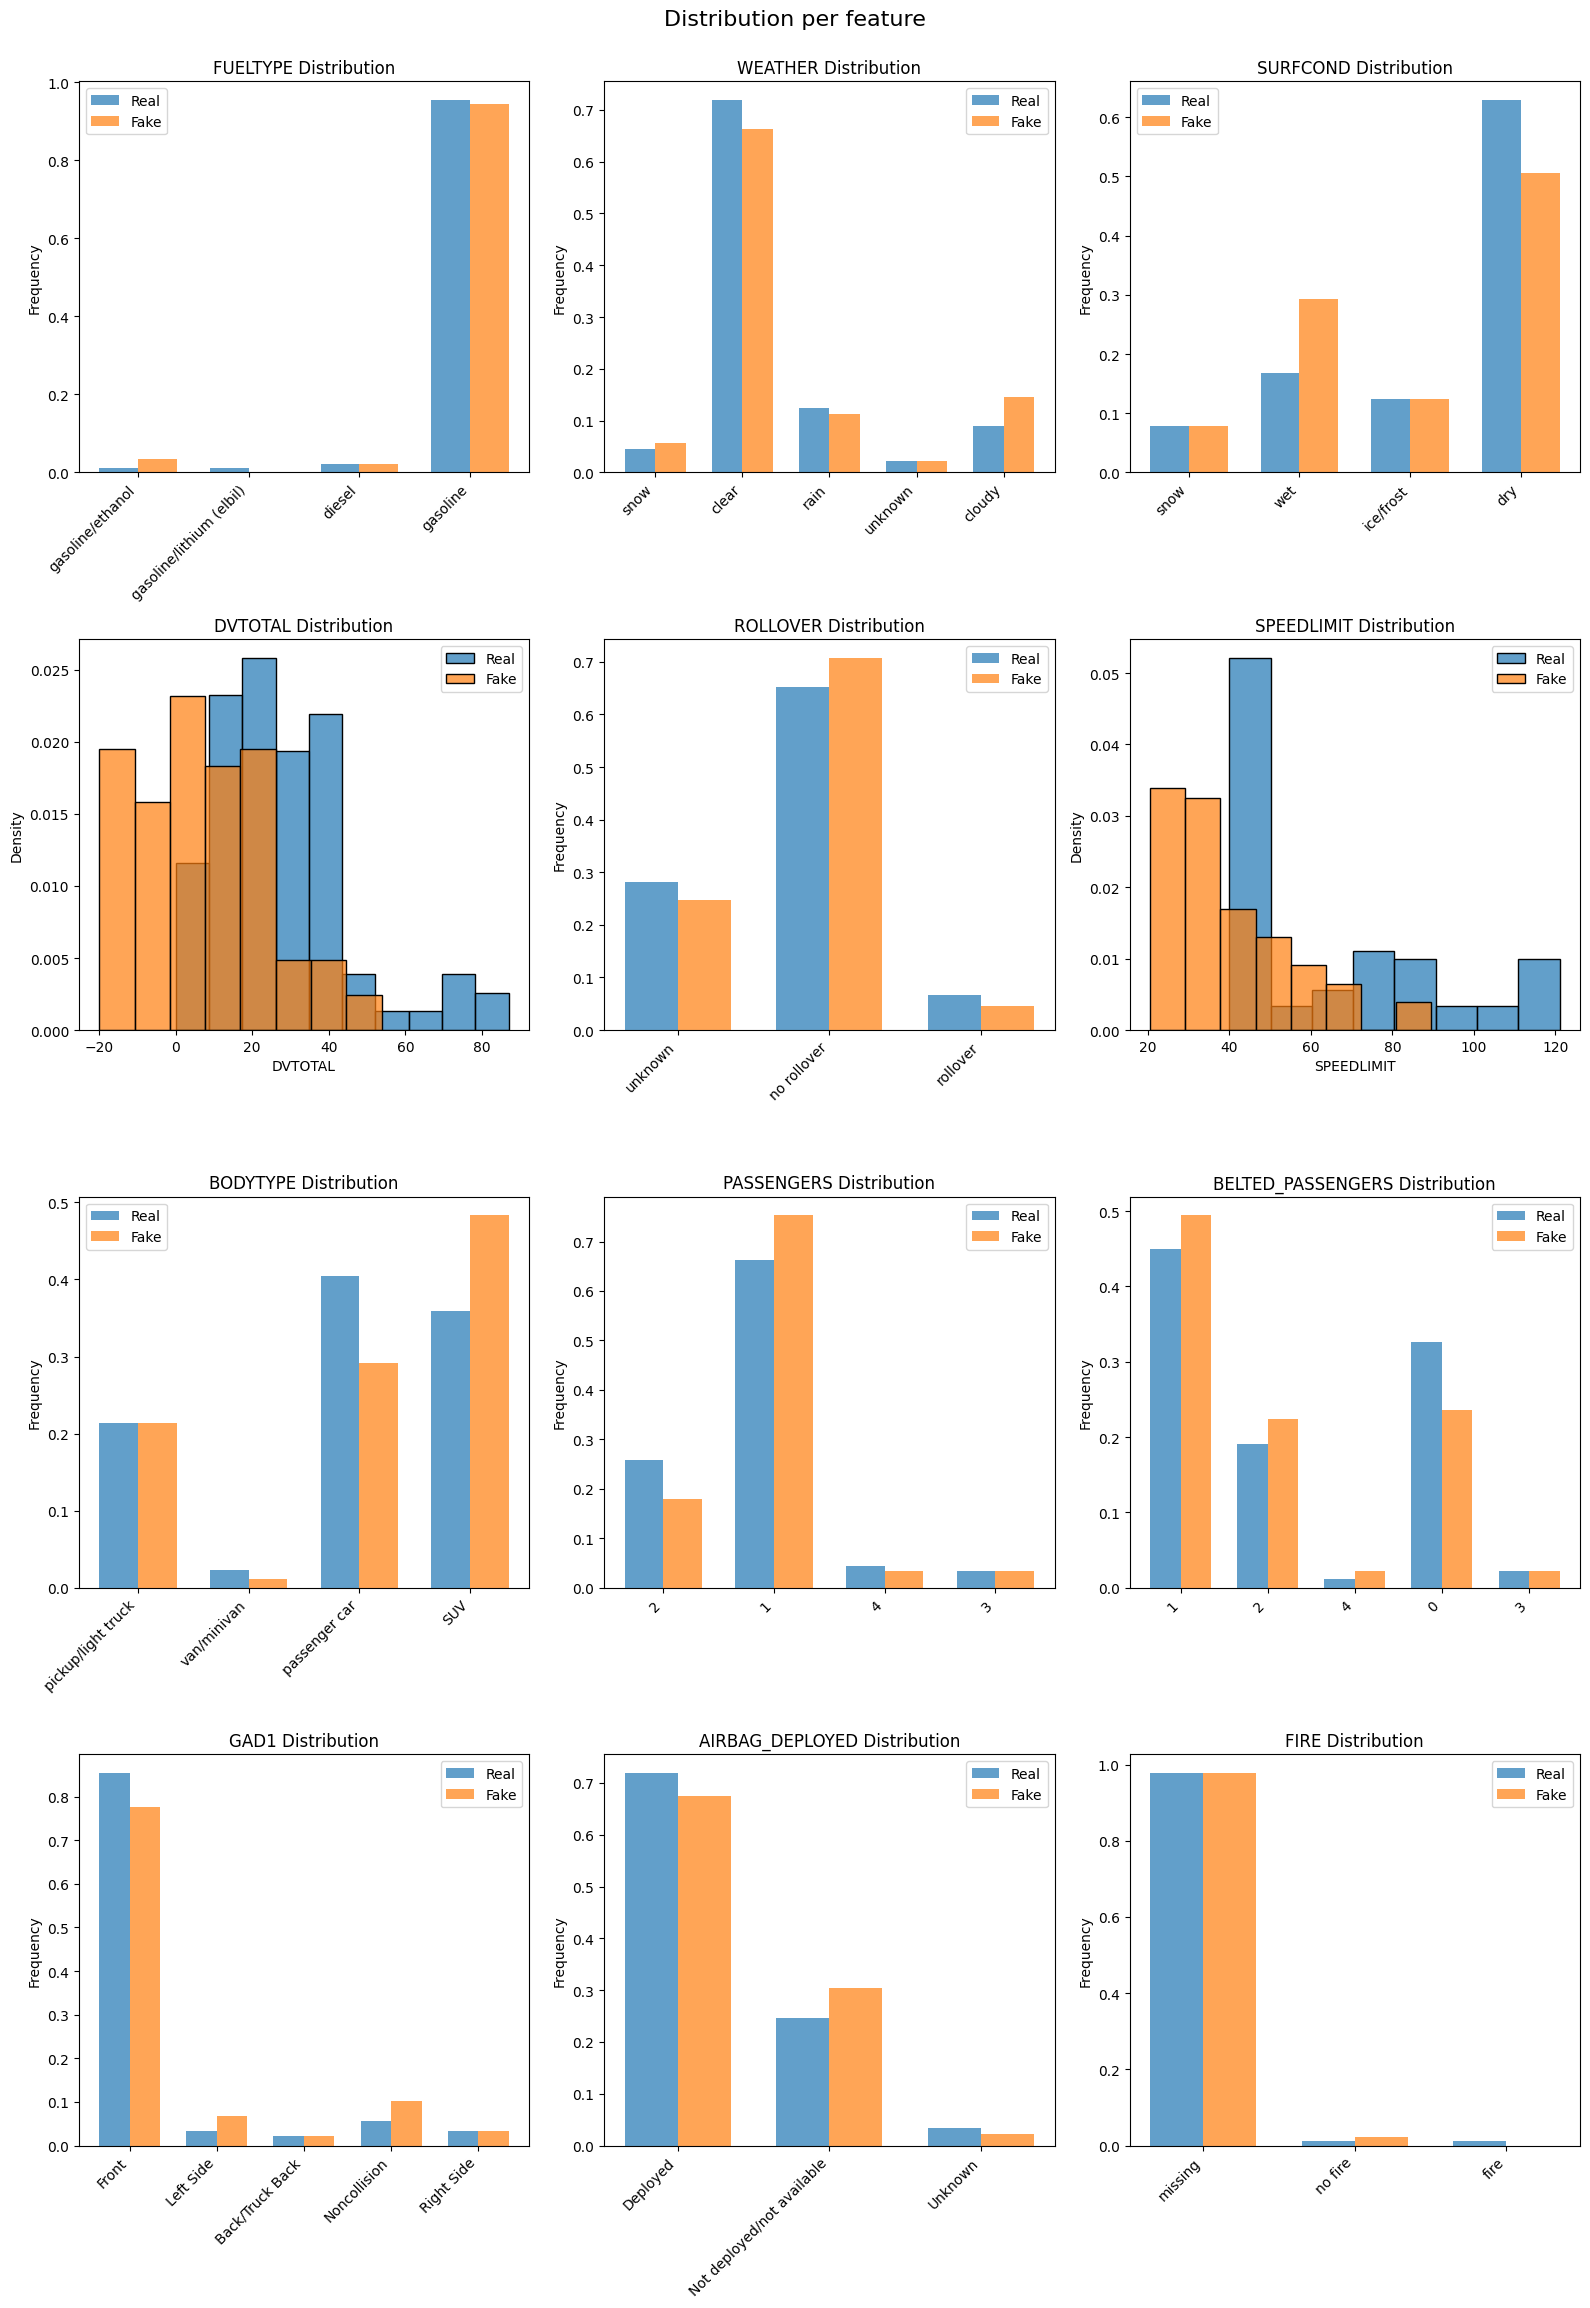

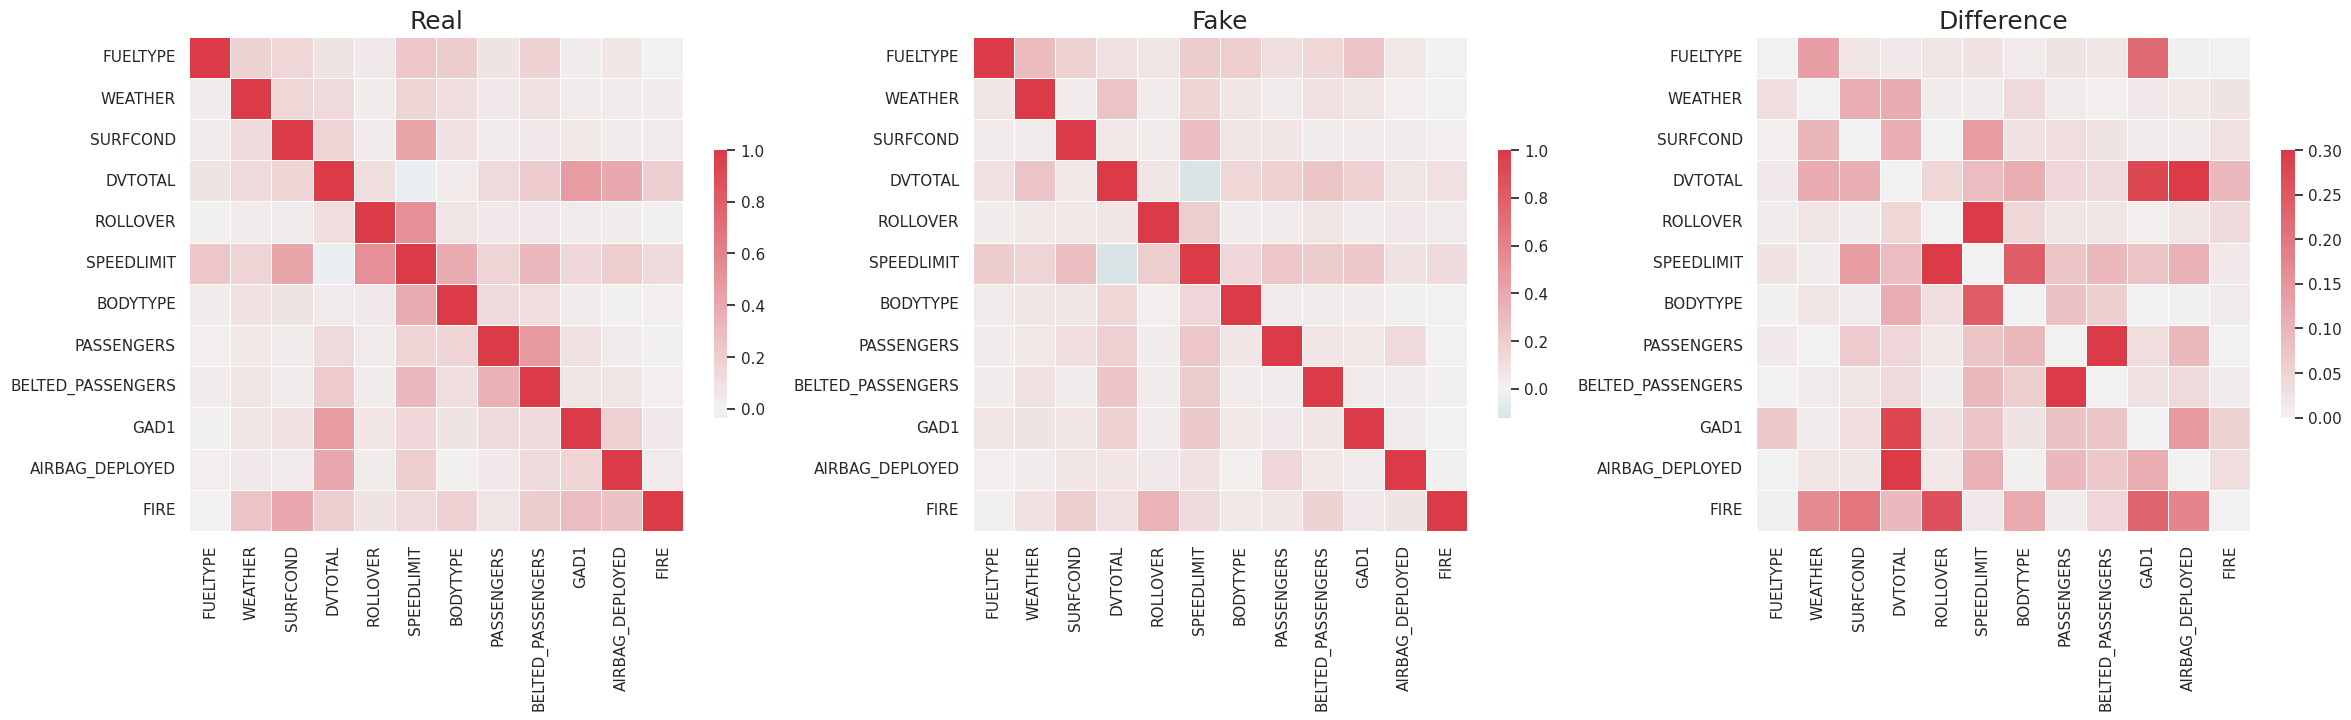

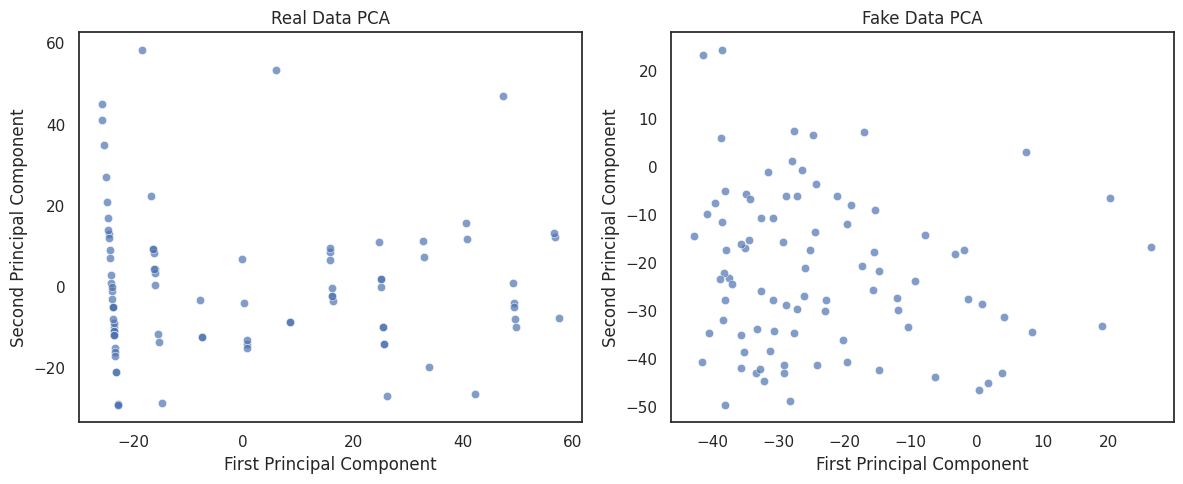

In [ ]:
from table_evaluator import TableEvaluator

print(data.shape, samples.shape)
table_evaluator = TableEvaluator(data, samples, cat_cols=categorical_features)
table_evaluator.visual_evaluation()

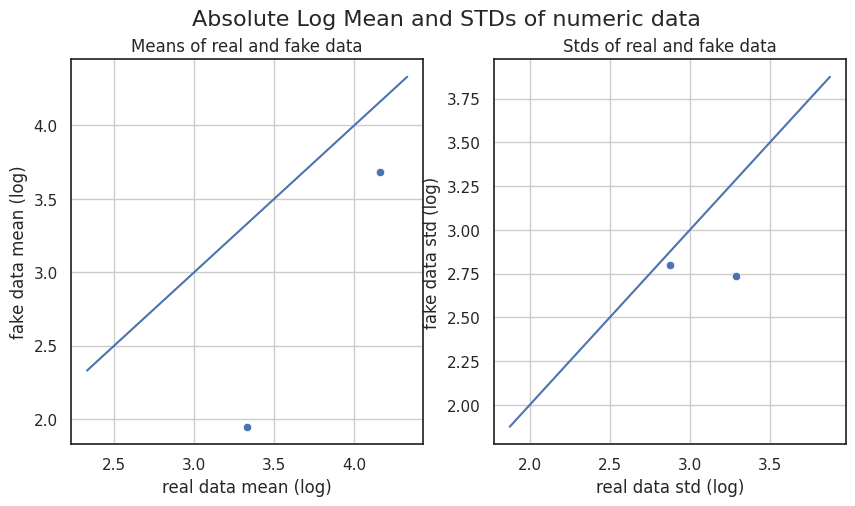

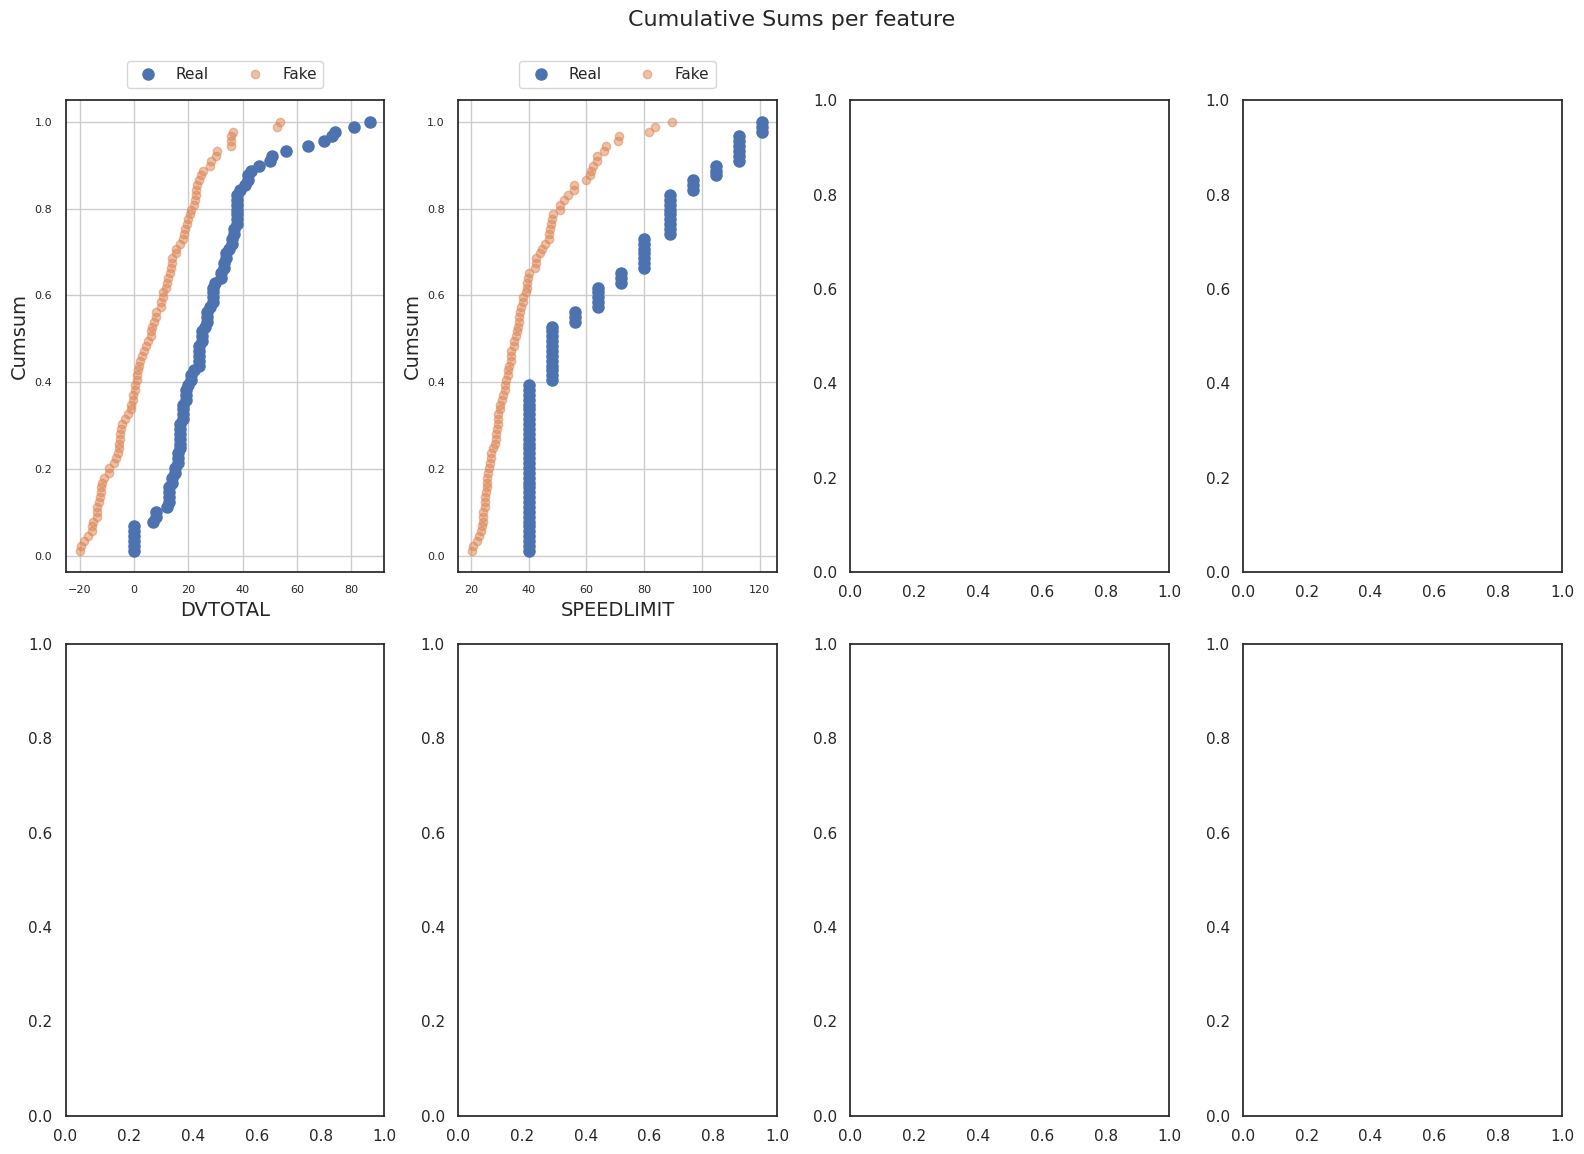

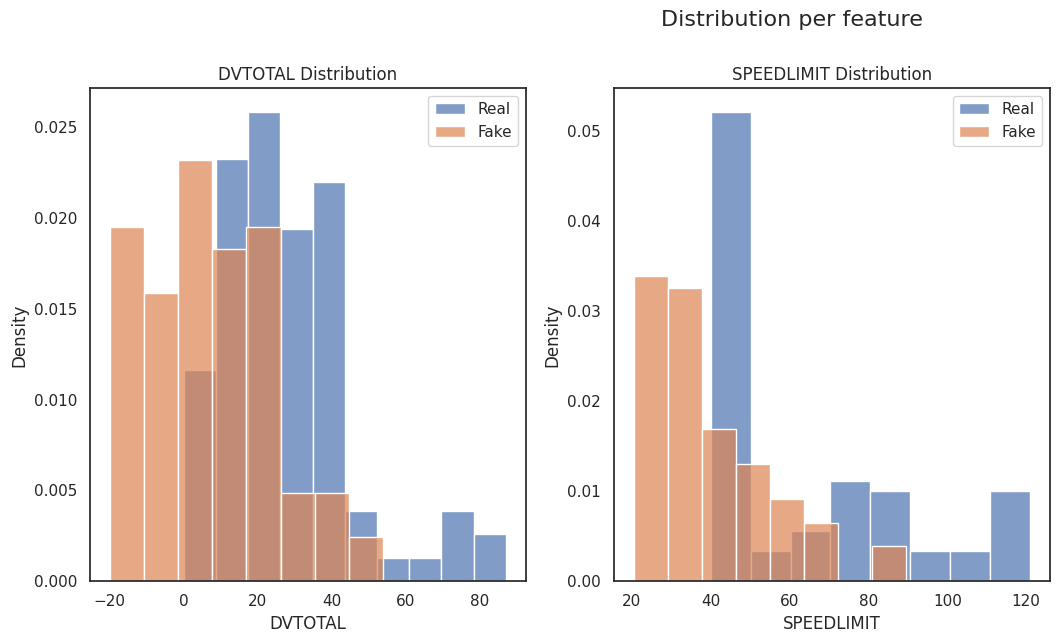

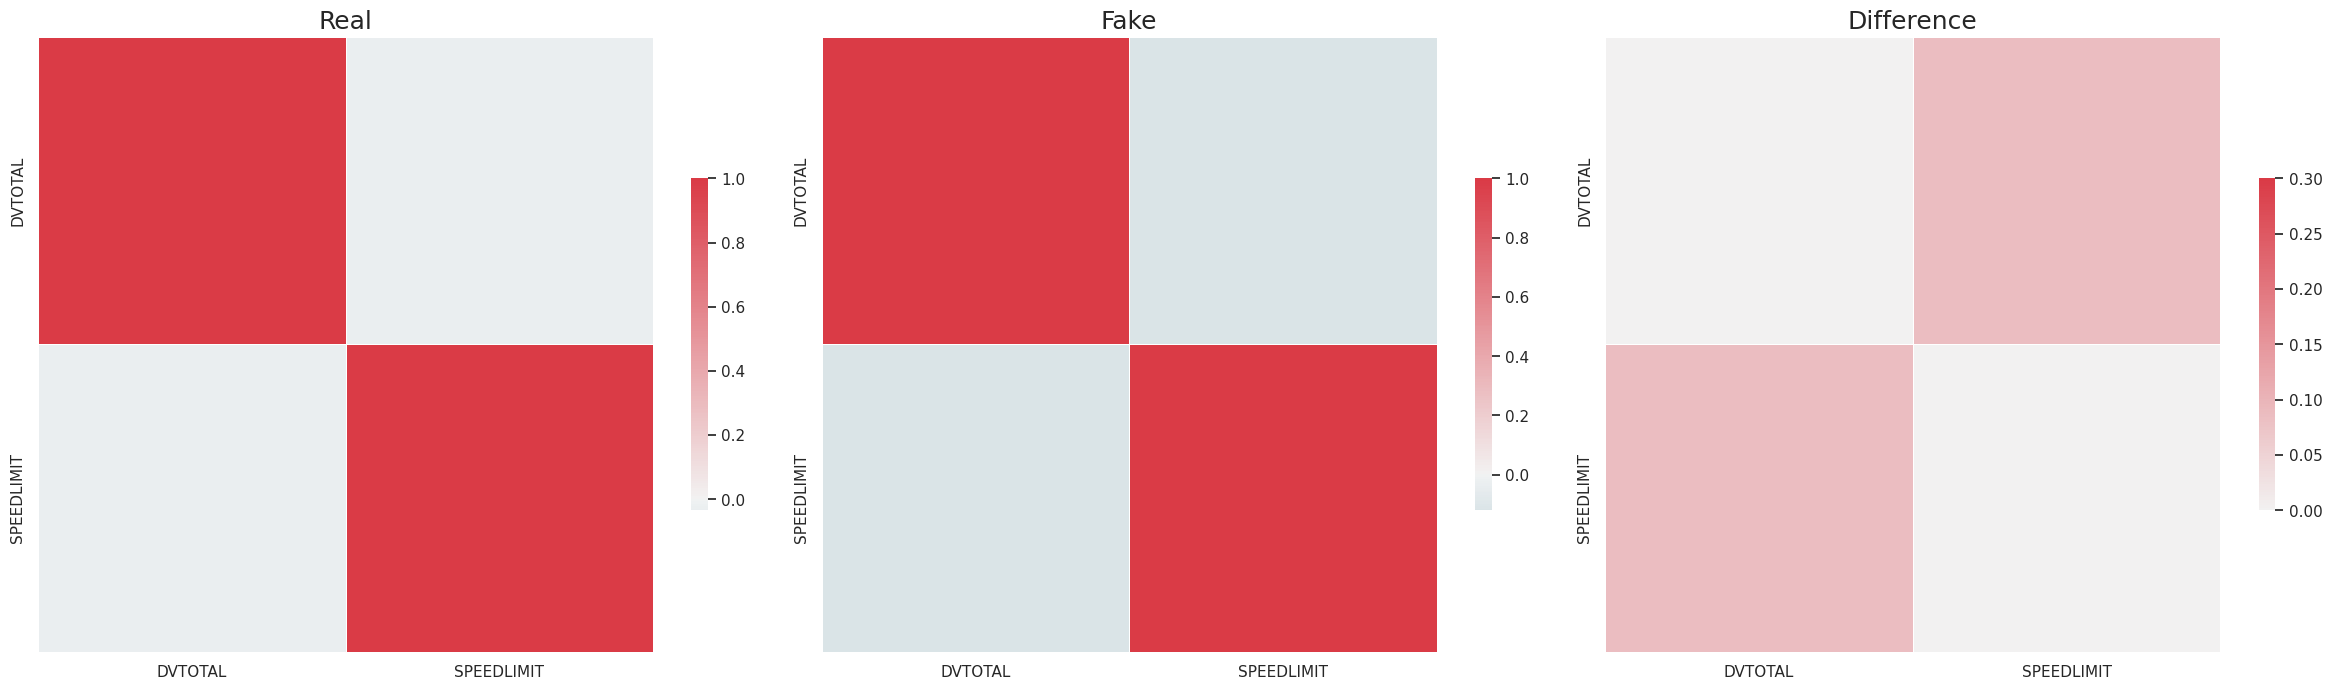

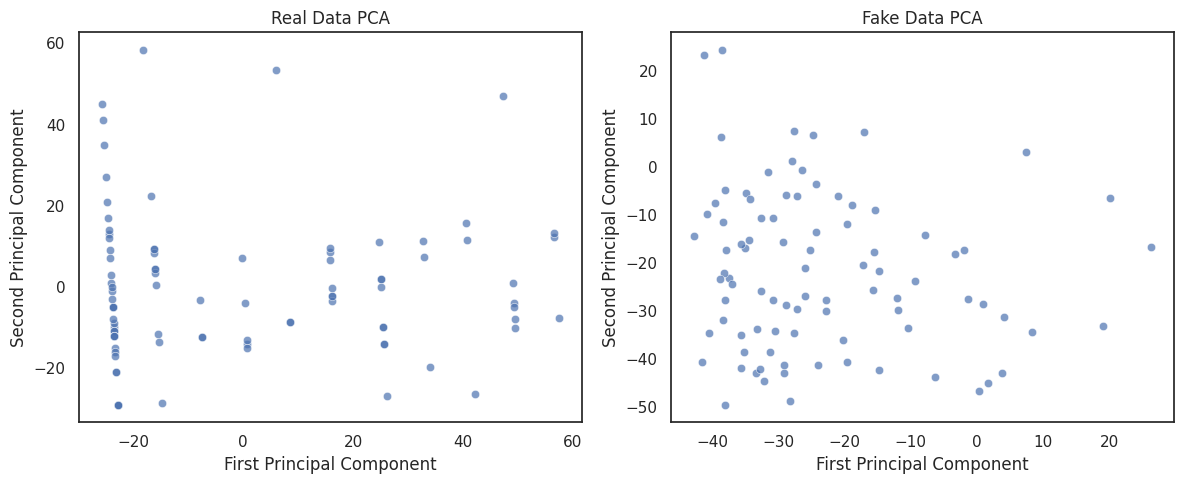

In [ ]:
num_cols = ['DVTOTAL', 'SPEEDLIMIT']

te_num = TableEvaluator(
    data[num_cols],
    samples[num_cols]
)


te_num.visual_evaluation()

In [ ]:
import json
import pandas as pd
import numpy as np

samples["DVTOTAL"] = pd.to_numeric(samples["DVTOTAL"], errors="coerce").replace(999, np.nan)
samples["SPEEDLIMIT"] = pd.to_numeric(samples["SPEEDLIMIT"], errors="coerce").replace(999, np.nan)

weather_map = {
    0: "Missing",
    1: "Clear",
    2: "Rain",
    3: "Sleet/Hail",
    4: "Snow",
    5: "Smoke/Fog",
    6: "Strong crosswind",
    8: "Cloudy",
    9: "Blowing snow",
    10: "Freezing rain"
}

rollover_map = {
    0: "Unknown",
    1: "No rollover",
    2: "Rollover"
}

surfcond_map = {
    0: "Missing",
    1: "Dry",
    2: "Wet",
    3: "Snow",
    4: "Slush",
    5: "Ice/Frost",
    6: "Water",
    8: "Gravel/Dirt"
}

bodytype_map = {
    1: "Passenger car",
    2: "SUV",
    3: "Pickup/Light truck",
    4: "Van/Minivan"
}

airbag_map = {
    0: "Unknown",
    1: "Deployed",
    2: "Not deployed/Not available"
}

fire_map = {
    0: "Missing",
    1: "No fire",
    2: "Fire",
    9: "Unknown"
}

fueltype_map = {
    1: "Gasoline",
    2: "Gasoline/Ethanol",
    4: "Diesel",
    11: "Gasoline/Lithium electric"
}

gad1_map = {
    "B": "Back/Truck Back",
    "C": "Rear of cab",
    "D": "Back (rear of tractor)",
    "F": "Front",
    "L": "Left Side",
    "N": "Noncollision",
    "R": "Right Side",
    "T": "Top",
    "U": "Undercarriage",
    "V": "Front of cargo area",
    "9": "Unknown"
}

code_system = "https://github.com/scubaduber/Kandidatarbete/blob/main/fhir/CodeSystem/crash-data.json"
patient_identifier_system = "https://scubaduber.github.io/Kandidatarbete/fhir/NamingSystem/synthetic-patient-id"

def get_text(value, mapping):
    if pd.isna(value):
        return "Unknown"
    numeric_value = pd.to_numeric(value, errors="coerce")
    if not pd.isna(numeric_value):
        return mapping.get(int(numeric_value), "Unknown")
    text_value = str(value).strip()
    return mapping.get(text_value, text_value)

def sanitize_code(text):
    return (
        str(text)
        .strip()
        .lower()
        .replace(" ", "-")
        .replace("/", "-")
        .replace("(", "")
        .replace(")", "")
        .replace(",", "")
    )

def make_code(label, code):
    return {
        "coding": [
            {
                "system": code_system,
                "code": code,
                "display": label
            }
        ],
        "text": label
    }

def make_value_codeable(text_value, value_code):
    return {
        "coding": [
            {
                "system": code_system,
                "code": value_code,
                "display": text_value
            }
        ],
        "text": text_value
    }

def add_codeable_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, text_value):
    value_code = sanitize_code(text_value)
    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueCodeableConcept": make_value_codeable(text_value, value_code),
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def add_quantity_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, value, unit=None):
    value_quantity = {"value": None if pd.isna(value) else float(value)}
    if unit is not None:
        value_quantity["unit"] = unit

    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueQuantity": value_quantity,
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def add_integer_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, value, unknown_codes=None):
    numeric_value = pd.to_numeric(value, errors="coerce")
    if pd.isna(numeric_value):
        final_value = None
    elif unknown_codes is not None and int(numeric_value) in unknown_codes:
        final_value = None
    else:
        final_value = int(numeric_value)

    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueInteger": final_value,
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def row_to_fhir_entries(row):
    patient_id = f"patient-{row.name}"
    encounter_id = f"encounter-{row.name}"

    entries = [
        {
            "fullUrl": f"urn:uuid:{patient_id}",
            "resource": {
                "resourceType": "Patient",
                "id": patient_id,
                "identifier": [
                    {
                        "system": patient_identifier_system,
                        "value": patient_id
                    }
                ]
            }
        },
        {
            "fullUrl": f"urn:uuid:{encounter_id}",
            "resource": {
                "resourceType": "Encounter",
                "id": encounter_id,
                "status": "finished",
                "subject": {
                    "reference": f"urn:uuid:{patient_id}"
                }
            }
        }
    ]

    add_quantity_observation(entries, patient_id, encounter_id, f"dvtotal-{row.name}", "Delta-V total", "dvtotal", row["DVTOTAL"], "deltaV")
    add_quantity_observation(entries, patient_id, encounter_id, f"speedlimit-{row.name}", "Speed limit", "speed-limit", row["SPEEDLIMIT"], "mph")

    add_codeable_observation(entries, patient_id, encounter_id, f"weather-{row.name}", "Weather", "weather", get_text(row["WEATHER"], weather_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"rollover-{row.name}", "Rollover", "rollover", get_text(row["ROLLOVER"], rollover_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"surfcond-{row.name}", "Surface condition", "surface-condition", get_text(row["SURFCOND"], surfcond_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"bodytype-{row.name}", "Body type", "body-type", get_text(row["BODYTYPE"], bodytype_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"airbag-{row.name}", "Airbag deployed", "airbag-deployed", get_text(row["AIRBAG_DEPLOYED"], airbag_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"fire-{row.name}", "Fire", "fire", get_text(row["FIRE"], fire_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"fueltype-{row.name}", "Fuel type", "fuel-type", get_text(row["FUELTYPE"], fueltype_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"gad1-{row.name}", "General area of damage", "general-area-of-damage", get_text(row["GAD1"], gad1_map))

    add_integer_observation(
        entries,
        patient_id,
        encounter_id,
        f"passengers-{row.name}",
        "Passengers",
        "passengers",
        row["PASSENGERS"],
        unknown_codes={0}
    )

    add_integer_observation(
        entries,
        patient_id,
        encounter_id,
        f"belted-passengers-{row.name}",
        "Belted passengers",
        "belted-passengers",
        row["BELTED_PASSENGERS"],
        unknown_codes={99}
    )

    provenance_id = f"provenance-{row.name}"
    entries.append(
        {
            "fullUrl": f"urn:uuid:{provenance_id}",
            "resource": {
                "resourceType": "Provenance",
                "id": provenance_id,
                "target": [
                    {"reference": f"urn:uuid:{patient_id}"},
                    {"reference": f"urn:uuid:{encounter_id}"}
                ],
                "recorded": "2026-04-21T10:00:00Z",
                "agent": [
                    {
                        "type": {
                            "text": "author"
                        },
                        "who": {
                            "display": "Synthetic crash data generation pipeline"
                        }
                    }
                ],
                "activity": {
                    "coding": [
                        {
                            "system": code_system,
                            "code": "synthetic-data-generation",
                            "display": "Synthetic data generation"
                        }
                    ],
                    "text": "Synthetic data generation"
                }
            }
        }
    )

    return entries

all_entries = []
for _, row in samples.iterrows():
    all_entries.extend(row_to_fhir_entries(row))

final_bundle = {
    "resourceType": "Bundle",
    "id": "synthetic-crash-bundle-1",
    "type": "collection",
    "entry": all_entries
}

print(json.dumps(final_bundle["entry"][:15], indent=2))

with open('/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle3.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

print("Saved final bundle to /content/drive/MyDrive/Colab Notebooks/fhir_final_bundle3.json")
print("Total resources in bundle:", len(final_bundle["entry"]))

[
  {
    "fullUrl": "urn:uuid:patient-0",
    "resource": {
      "resourceType": "Patient",
      "id": "patient-0",
      "identifier": [
        {
          "system": "https://scubaduber.github.io/Kandidatarbete/fhir/NamingSystem/synthetic-patient-id",
          "value": "patient-0"
        }
      ]
    }
  },
  {
    "fullUrl": "urn:uuid:encounter-0",
    "resource": {
      "resourceType": "Encounter",
      "id": "encounter-0",
      "status": "finished",
      "subject": {
        "reference": "urn:uuid:patient-0"
      }
    }
  },
  {
    "fullUrl": "urn:uuid:dvtotal-0",
    "resource": {
      "resourceType": "Observation",
      "id": "dvtotal-0",
      "status": "final",
      "code": {
        "coding": [
          {
            "system": "https://github.com/scubaduber/Kandidatarbete/blob/main/fhir/CodeSystem/crash-data.json",
            "code": "dvtotal",
            "display": "Delta-V total"
          }
        ],
        "text": "Delta-V total"
      },
      "value

In [ ]:
print(samples.columns.tolist())

['FUELTYPE', 'WEATHER', 'SURFCOND', 'DVTOTAL', 'ROLLOVER', 'SPEEDLIMIT', 'BODYTYPE', 'PASSENGERS', 'BELTED_PASSENGERS', 'GAD1', 'AIRBAG_DEPLOYED', 'FIRE']


In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle3.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/fhir_bundles3.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle3.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>